# §1 Individual (unfiltered) — net of costs

Per-combo metrics and per-combo equity/drawdown curves on the
20% OOS test partition with no ML#2 filter. Two sizing policies
compared: `fixed_dollars_500` and `pct5_compound`.

**Cost model:** every trade is charged `contracts × $5.00` round-trip (≈ $3 retail commission + 2 ticks/side slippage on MNQ at $0.50/tick). Applied to both sizing policies.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd

REPO = Path.cwd().resolve()
while not (REPO / 'src').exists() and REPO.parent != REPO:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

from scripts.evaluation._top_perf_common import (
    STARTING_EQUITY, RISK_FRAC, POLICIES,
    apply_sizing, metrics_from_pnl, monte_carlo,
    load_setup,
    plot_indiv_equity, plot_indiv_dd,
    plot_combined_equity, plot_combined_dd,
    plot_ml2_indiv_equity, plot_ml2_indiv_dd,
    plot_ml2_combined_equity, plot_ml2_combined_dd,
    plot_mc_sims, plot_mc_pnl, plot_mc_sharpe, plot_mc_dd,
)

_ctx = load_setup(cost_per_contract_rt=5.0)
bars            = _ctx['bars']
YEARS_SPAN      = _ctx['years_span']
strategies      = _ctx['strategies']
results_raw     = _ctx['results_raw']
combined_raw    = _ctx['combined_raw']
combos_ml2      = _ctx['combos_ml2']
s4_pnl_by_combo = _ctx['s4_pnl_by_combo']
ml2_portfolio   = _ctx['ml2_portfolio']


Test partition: 514,563 bars  2024-10-22 05:08:00 -> 2026-04-08 20:20:00
Years span: 1.461  (used to annualize Sharpe)
Applying friction: $5.00/contract RT (commission + slippage).
Loaded 10 strategies.
Loaded results_raw from cache (10 combos).
Combined unfiltered trades: 11,851
Loaded combos_ml2 from cache (10 combos).


ML2 portfolio trade counts: {'fixed_dollars_500': 119, 'pct5_compound': 119}


In [2]:
rows = []
for r in results_raw:
    if r['trades'].empty:
        for policy in POLICIES:
            rows.append({'combo_id': r['combo_id'], 'policy': policy,
                         **metrics_from_pnl(np.array([]), YEARS_SPAN, policy=policy)})
        continue
    t = r['trades'].sort_values('date', kind='mergesort')
    pnl_base = t['actual_pnl'].to_numpy(dtype=float)
    risk_base = t['dollar_risk'].to_numpy(dtype=float)
    r_mult = np.where(risk_base > 0, pnl_base / risk_base, 0.0)
    for policy in POLICIES:
        pnl = apply_sizing(pnl_base, risk_base, policy)
        rows.append({'combo_id': r['combo_id'], 'policy': policy,
                     **metrics_from_pnl(pnl, YEARS_SPAN, policy=policy, r=r_mult)})
perf1 = pd.DataFrame(rows)
perf1

,combo_id,policy,n_trades,trades_per_year,win_rate,total_pnl_dollars,total_return_pct,sharpe_ratio,max_drawdown_pct,max_drawdown_dollars
0,v10_9955,fixed_dollars_500,220,150.6,0.7182,-39746.52,-79.49,-4.1152,79.56,39902.56
1,v10_9955,pct5_compound,220,150.6,0.7182,-49364.58,-98.73,-4.3032,98.75,50146.77
2,v5_2725,fixed_dollars_500,23,15.7,0.7391,-664.62,-1.33,-0.2700,7.26,3764.39
3,v5_2725,pct5_compound,23,15.7,0.7391,-4227.78,-8.46,-0.3447,32.80,19690.81
4,v9_837,fixed_dollars_500,13,8.9,0.0000,-3463.41,-6.93,-2.1031,6.93,3463.41
5,v9_837,pct5_compound,13,8.9,0.0000,-15191.45,-30.38,-2.0525,30.38,15191.45
6,v10_4391,fixed_dollars_500,226,154.7,0.6372,-21687.71,-43.38,-2.0353,51.65,25827.10
7,v10_4391,pct5_compound,226,154.7,0.6372,-46263.30,-92.53,-2.3472,94.58,47287.65
8,v10_1214,fixed_dollars_500,543,371.7,0.1786,-85362.34,-170.72,-3.0342,188.75,96574.66
9,v10_1214,pct5_compound,543,371.7,0.1786,-49999.40,-100.00,-4.2196,100.00,52710.39


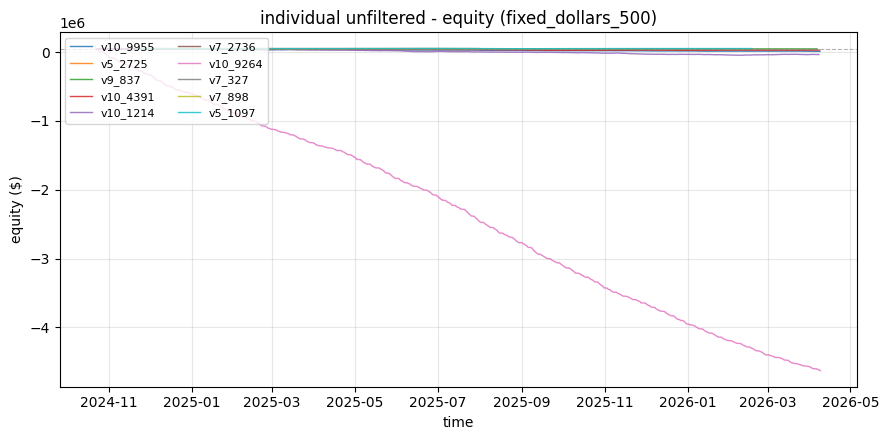

In [3]:
plot_indiv_equity(results_raw, 'fixed_dollars_500')

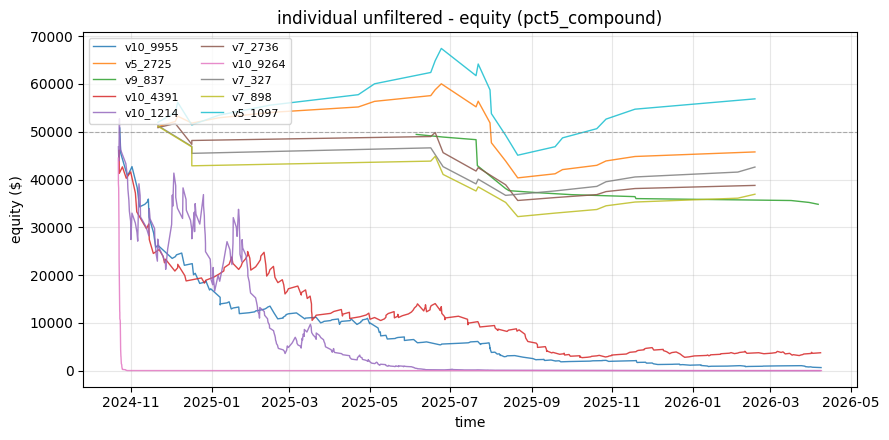

In [4]:
plot_indiv_equity(results_raw, 'pct5_compound')

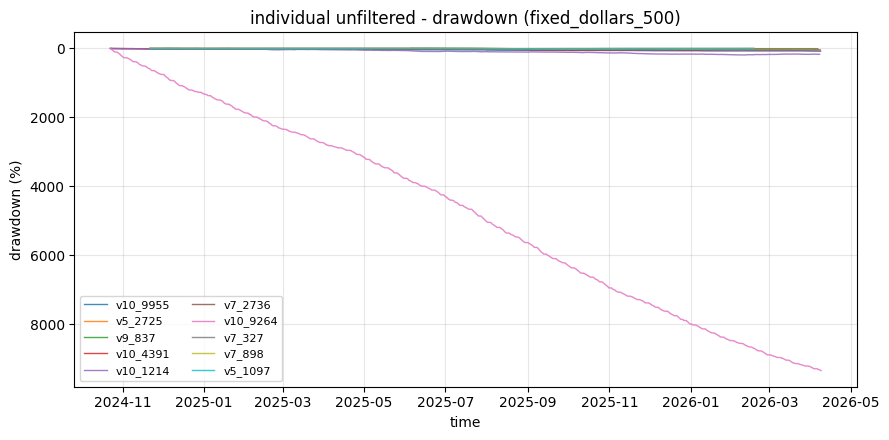

In [5]:
plot_indiv_dd(results_raw, 'fixed_dollars_500')

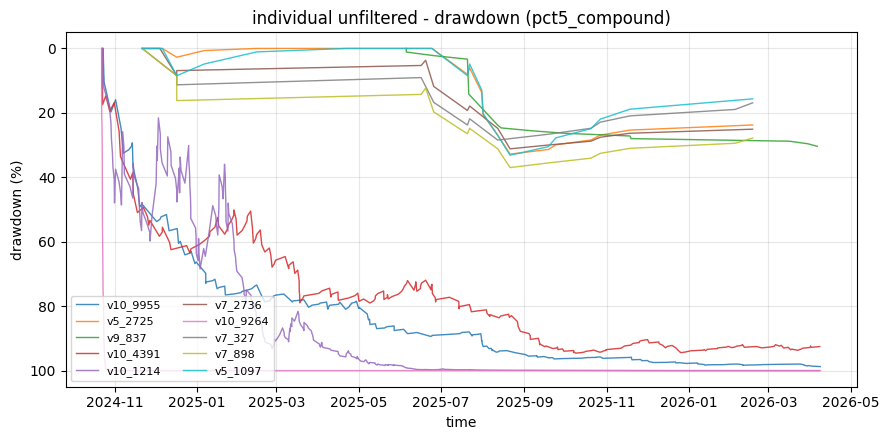

In [6]:
plot_indiv_dd(results_raw, 'pct5_compound')